================================================================================
# ANEXO

## PROBABLES MEJORAS A FUTURO        version 26 / 3-nov 02:17


### *Trabajo en curso*

1 Crear lista categorias = df_ventas_final["categoria"].unique()  

2 Crear tabla df_producto con id_producto, producto, id_categoria, categoria

Se observó que:
1. Las ventas contienen productos con la misma denominación, sin ninguna id como para identificarlos. Pertenecen a distintas ventas individuales y tienen distinto precio.

2. Por tal razón es dificil hacer una evaluación seria del resultado de la campaña publicitaria, porque corresponde a distintos productos agrupados, con precio sin adjudicar.

3. La campaña de marketing posee el costo publicitario por producto (generico/agregado) pero no hay como relacionarlo con el costo_unitario, ni con el precio_venta

4. Sacar un precio_promedio, no estoy seguro que sirva mucho, porque la venta podria haberse hecho a un valor menor que el precio_unitario_promedio, debido a la gran dispersión de precios

Hemos visto que para el producto "Adorno de pared", los precios estan distibuidos en 3 segmentos o rangos, la idea es hacer un promedio por rango y
luego renombrar los productos segun el rango, por ej:
"Adorno de pared" => "Adorno de pared R1"

De esta manera en lugar de tener 100 productos genericos los tendriamos divididos por rango de precios y con un nuevo nombre_producto que los represente
  


.  

## Por este motivo el DF df_producto, y df_pp_ventas van a ir evolucionando....  

.

In [ ]:
import pandas as pd

# Import dataset ventas final
url = "https://raw.githubusercontent.com/alex-degarate/TT-2C2025-Data-Analitycs-Notebooks/main/PreEntrega/Datasets/"

#df_ventas_final = pd.read_csv( url + "ventas_final.csv")


In [ ]:
# Import dataset clientes
#df_clientes_final = pd.read_csv( url + "clientes_final.csv")

In [ ]:
# Import dataset marketing
df_marketing_final = pd.read_csv( url + "marketing_final.csv")

In [ ]:
df_marketing_final.info()


## a partir de ahora vamos a trabajar con df_pp_ventas2 / 4 (desde disco)

In [1]:
import pandas as pd

### archivos para probar puntos finales

In [2]:
# a partir de ahora vamos a trabajar con df_pp_ventas2 /4
url2 ="https://raw.githubusercontent.com/alex-degarate/DAnalytics/main/preproyecto/Datasets/tempo/"
df_pp_ventas = pd.read_csv( url2 + "df_pp_ventas4.csv",index_col=0 )


In [3]:
# @title
## Hacemos una copia para hacer pruebas o si la IA lo arruina
df_pp_ventas2 = df_pp_ventas.copy()
df_pp_ventas2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 0 to 2997
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     2998 non-null   int64  
 1   id_producto  2998 non-null   int64  
 2   producto     2998 non-null   object 
 3   precio_unit  2998 non-null   float64
 4   cantidad     2998 non-null   int64  
 5   fecha_venta  2998 non-null   object 
 6   categoria    2998 non-null   object 
 7   rango        100 non-null    object 
dtypes: float64(1), int64(3), object(4)
memory usage: 210.8+ KB


In [4]:
df_pp_ventas2.head()

,id_venta,id_producto,producto,precio_unit,cantidad,fecha_venta,categoria,rango
0,792,0,Cuadro decorativo,69.94,5,2024-01-02,Decoración,NaN
1,811,0,Lámpara de mesa,105.10,5,2024-01-02,Decoración,NaN
2,1156,0,Secadora,97.96,3,2024-01-02,Electrodomésticos,NaN
3,1372,0,Heladera,114.35,8,2024-01-02,Electrodomésticos,NaN
4,1546,0,Secadora,106.21,4,2024-01-02,Electrodomésticos,NaN


## Lista alfabetica de productos

In [16]:

lista_productos = ["Adorno de pared","Alfombra","Aspiradora","Auriculares","Batidora","Cafetera","Candelabro",
"Consola de videojuegos","Cortinas","Cuadro decorativo","Cámara digital","Elementos de cerámica","Espejo decorativo","Freidora eléctrica","Heladera",
"Horno eléctrico","Jarrón decorativo","Laptop","Lavadora","Lámpara de mesa","Microondas","Parlantes Bluetooth","Plancha de vapor ","Proyector","Rincón de plantas","Secadora","SmartWatch","Smartphone","Tablet","Televisor"]

# Creamos una lista de listas, agregando el segundo elemento vacío, para llevar
# control de lo procesado

aLista_prod = [[nombre, 0] for nombre in lista_productos]


In [163]:

# Convert the list of lists to a DataFrame
df_aLista_prod = pd.DataFrame(aLista_prod, columns=['Producto', 'Procesado'])

df_aLista_prod.iat[0, 1] = 1  # Adorno de pared
df_aLista_prod.iat[9, 1] = 1  # Cuadro decorativo

# Display the DataFrame
display(df_aLista_prod)

,Producto,Procesado
0,Adorno de pared,1
1,Alfombra,0
2,Aspiradora,0
3,Auriculares,0
4,Batidora,0
5,Cafetera,0
6,Candelabro,0
7,Consola de videojuegos,0
8,Cortinas,0
9,Cuadro decorativo,1


In [ ]:
#df_pp_ventas[ df_pp_ventas["producto"] == "Adorno de pared"].count()
# "producto"] == "Adorno de pared"] hay => 100
#df_pp_ventas.sort_values(by="producto", ascending=True, inplace=False)
#df_pp_ventas[ df_pp_ventas["producto"] == "Adorno de pared"]


In [ ]:
#df_pp_ventas = df_pp_ventas.sort_values(by="producto", ascending=True)
#df_pp_ventas[df_pp_ventas["producto"] == "Adorno de pared"].head(100)

#sort_values(by="valor_venta", ascending=False, inplace=True)
#df_pp_ventas.head()

# Utilizaremos el que esta en curso df_producto5
Para hacer de enlace como clave primaria entre ventas y marketing


In [ ]:
# @title
# ventas_categoria.sort_values(by="valor_venta", ascending=False, inplace=True)
# mal df_pp_ventas[df_pp_ventas["producto"]].sum()

# IMPRIMIR la lista de productos ordenados alfabeticamente y las ventas
#----------------------------------------------------
# df_pp_ventas["producto"].value_counts().sort_index()
#---------------------------------------------------

,count
producto,
Adorno de pared,100
Alfombra,100
Aspiradora,100
Auriculares,143
Batidora,100
Cafetera,117
Candelabro,24
Consola de videojuegos,99
Cortinas,100


## El DF df_producto5 es el que esta actualizado y el que debe cargarse desde github

In [9]:
url2 ="https://raw.githubusercontent.com/alex-degarate/DAnalytics/main/preproyecto/Datasets/tempo/"

# OJO ! se levanta como df_producto
df_producto = pd.read_csv( url2 + "df_producto5.csv", index_col=0 )
#df_producto.info()



In [ ]:
#df_producto.head(15)


### Aparecieron imprevistos que complican el codigo, y tengo que reintroducir el nombre generico del producto, independiente del rango a que pertenezca.   
## Tanto a producto como  a pp_ventas

In [12]:
df_producto['prod_gener'] = df_producto['producto'].str.replace('-R[123]', '', regex=True)
display(df_producto.head())

,id_producto,producto,id_categoria,categoria,rango,media_rango,precio_rango,prod_gener
0,101,Adorno de pared-R1,1,Decoración,R1,44.39,25-66,Adorno de pared
1,102,Adorno de pared-R2,1,Decoración,R2,78.29,66-91,Adorno de pared
2,103,Adorno de pared-R3,1,Decoración,R3,105.74,91-120,Adorno de pared
3,111,Alfombra-R1,1,Decoración,R1,0.00,NaN,Alfombra
4,112,Alfombra-R2,1,Decoración,R2,0.00,NaN,Alfombra


In [ ]:
'''
copio producto2 e. producto3 agregando los rangos
arango = ["","R1","R2","R3"]
nLenght2 = df_producto2.shape[0]

myid = 100
idx3 = 1

for index in range(nLenght2):

    idx = index
    # Select the row at index 0 from df_producto2
    row_to_copy = df_producto2.iloc[idx]
    #print(row_to_copy)

    nomP = df_producto2.iat[index, 1]
    idcat= df_producto2.iat[index, 2]
    catP = df_producto2.iat[index, 3]

    for j in range(1, 4):  # de 1-3
        # Append the selected row to df_producto3
        myid += 1
        df_producto3.loc[idx3] = [myid, nomP +'-'+ arango[j], idcat, catP, arango[j]]
        idx3 += 1
        #df_producto3 = pd.concat([df_producto3, pd.DataFrame([row_to_copy])], ignore_index=True)

    myid += 7

   '''

### guardamos df_producto como producto9.csv para su uso posterior

In [13]:
# @title
# guardamos df_producto para su uso posterior, incrementar el digito al guardar

def guardar_df_a_csv(df, nombre_archivo):
    df.to_csv(nombre_archivo, index=True)
    print(f"DataFrame guardado como {nombre_archivo}")

# Llamada a la función para guardar df_
# guardar_df_a_csv( df_producto4, 'df_producto5.csv')

df_producto.to_csv('df_producto5.csv', index=True)

# df_pp_ventas.to_csv('df_pp_ventas4.csv', index=True)


================================================================================

.

# PASOS PARA AUTOMATIZAR
## PARA TODOS LOS PRODUCTOS

### 1. Recorrer La lista de productos,
&emsp; si el 2do campo esta en cero significa que no fue procesado, 1=completo
lista_productos = [["Adorno de pared", 1]

### 2. OBTENER NOMBRE DEL PRODUCTO A PROCESAR

### 3. CREAR EL DF TEMPORAL

### 4. VISUALIZAR ESTADISTICA CON DESCRIBE

### 5 CALCULAR RANGOS, MEDIA

### 6. CALCULAR Cuartiles (0.33 y 0.66)

### 7. GRAFICAR HISTOGRAMA

### 8. REEMPLAZAR DATOS EN DF TEMPORAL

### 9. ACTUALIZAR df_pp_ventas


## 2. OBTENER NOMBRE DEL PRODUCTO A PROCESAR

In [238]:
'''
# Iterar sobre cada fila del DataFrame

for index, row in df_aLista_prod.iterrows():
    idx = index
    fila = df_aLista_prod.iloc[idx]
    #print(fila)
    prod_actual = fila['Producto']

    if row['Procesado'] == 0:
        prod_actual = row['Producto']
        print(f"Procesando producto: {prod_actual}")
'''
nLenght = df_aLista_prod.shape[0]
print(f"{nLenght}")

for i in range( nLenght):

    if df_aLista_prod.iat[i, 1] == 0:
       prod_actual = df_aLista_prod.iat[i, 0]      # nombre producto
       print(f"{prod_actual}")
       break

print(f"El primer registro a procesar es {[i]}: {prod_actual}")

30
Alfombra
El primer registro a procesar es [1]: Alfombra


# Cuadro decorativo

In [239]:
#prod_actual = "Cuadro decorativo"
print( df_pp_ventas2[ df_pp_ventas2["producto"] == prod_actual].count())

id_venta       100
id_producto    100
producto       100
precio_unit    100
cantidad       100
fecha_venta    100
categoria      100
rango            0
dtype: int64


In [197]:
# df_pp_ventas2 = df_pp_ventas.sort_values(by="producto", ascending=True)
df_pp_ventas2[df_pp_ventas2["producto"] == prod_actual].head(10)


,id_venta,id_producto,producto,precio_unit,cantidad,fecha_venta,categoria,rango
69,315,0,Alfombra,122.07,9,2024-01-10,Decoración,NaN
155,395,0,Alfombra,33.48,12,2024-01-19,Decoración,NaN
202,85,0,Alfombra,71.14,2,2024-01-25,Decoración,NaN
289,695,0,Alfombra,51.29,2,2024-02-03,Decoración,NaN
324,895,0,Alfombra,102.72,2,2024-02-07,Decoración,NaN
331,745,0,Alfombra,50.02,12,2024-02-08,Decoración,NaN
343,135,0,Alfombra,78.47,1,2024-02-10,Decoración,NaN
357,205,0,Alfombra,108.67,4,2024-02-11,Decoración,NaN
406,275,0,Alfombra,36.14,8,2024-02-18,Decoración,NaN
463,365,0,Alfombra,58.82,9,2024-02-24,Decoración,NaN


## 3. CREAR EL DF TEMPORAL
### df_actual corresponde a df_.....
la idea es generalizarlo para el procesamiento de los otros productos

In [ ]:
'''
# Drop the 'Unnamed: 0' column
if 'Unnamed: 0' in df_pp_ventas2.columns:
    df_pp_ventas2 = df_pp_ventas2.drop('Unnamed: 0', axis=1)

'''

In [240]:
# Generamos una tabla aislada para el producto actual =>

# df_actual corresponde a
df_actual = df_pp_ventas2[df_pp_ventas2["producto"] == prod_actual].copy()

media = df_actual["precio_unit"].mean()
print(f"El precio promedio para '{prod_actual}' es: {media:.2f} \n")

df_actual.describe()


El precio promedio para 'Alfombra' es: 74.10 



,id_venta,id_producto,precio_unit,cantidad
count,100.00000,100.0,100.000000,100.000000
mean,500.00000,0.0,74.098300,6.150000
std,290.11492,0.0,29.559892,3.761514
min,5.00000,0.0,27.680000,1.000000
25%,252.50000,0.0,47.735000,3.000000
50%,500.00000,0.0,71.035000,6.000000
75%,747.50000,0.0,97.607500,10.000000
max,995.00000,0.0,124.910000,12.000000


In [241]:
df_actual.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 69 to 2989
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     100 non-null    int64  
 1   id_producto  100 non-null    int64  
 2   producto     100 non-null    object 
 3   precio_unit  100 non-null    float64
 4   cantidad     100 non-null    int64  
 5   fecha_venta  100 non-null    object 
 6   categoria    100 non-null    object 
 7   rango        0 non-null      object 
dtypes: float64(1), int64(3), object(4)
memory usage: 7.0+ KB


### Completar en df_actual la columna ["rango"]

### 4. VISUALIZAR ESTADISTICA CON DESCRIBE

### Obtenemos info relevante mediante describe()

### 5 CALCULAR RANGOS, MEDIA

In [242]:

# Como accedo a los distintos datos de df_xxx.describe(),
# como ser min, max, etc
'''
The .describe() method in pandas returns a new DataFrame containing the
descriptive statistics.
You can access the individual statistics (like min, max, mean, etc.) from this
DataFrame using standard indexing.
'''
# Obtenemos la salida describe del DataFrame
#-------------------------------------------
def obtener_descripcion_DF(df):
    return df.describe()

df_desc = obtener_descripcion_DF( df_actual["precio_unit"])

#cuadro_decorativo_description = df_cuadro_decorativo["precio_unit"].describe()

# Accedemos a valores especificos
min_precio = int( round( df_desc['min']))
max_precio = int( round( df_desc['max']))
mean_precio = df_desc['mean']

print(f"PUnit Minimo: {min_precio}")
print(f"PUnit Maximo: {max_precio}")
print(f"PUnit Medio : {mean_precio:.2f} \n")

display (df_desc)

PUnit Minimo: 28
PUnit Maximo: 125
PUnit Medio : 74.10 



,precio_unit
count,100.000000
mean,74.098300
std,29.559892
min,27.680000
25%,47.735000
50%,71.035000
75%,97.607500
max,124.910000


In [243]:
if (max_precio / min_precio) > 2:
  print('HAY DISPERSION de precios !!!')
else:
  print( 'No hay dispersion de precios')

HAY DISPERSION de precios !!!



### 6. CALCULAR Cuartiles (0.33 y 0.66)

In [244]:
# df_actual = df_cuadro_decorativo

# Calculamos percentilo 33 de 'precio_unit'
q33_data = df_actual["precio_unit"].quantile(0.33)

# Calculamos el percentilo 66 de 'precio_unit'
q66_data = df_actual["precio_unit"].quantile(0.66)

print(f"El percentilo 33 del precio_unit para '{prod_actual}' es: {q33_data:.2f}")
print(f"El percentilo 66 del precio_unit para '{prod_actual}' es: {q66_data:.2f}")


El percentilo 33 del precio_unit para 'Alfombra' es: 53.96
El percentilo 66 del precio_unit para 'Alfombra' es: 88.90


### 7. GRAFICAR HISTOGRAMA

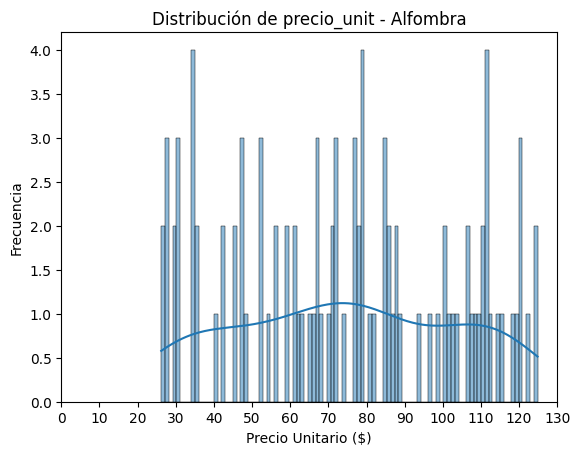

In [245]:
# @title
# Agregamos un plot para visualizar graficamente la distribución
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.histplot( df_cuadro_decorativo["precio_unit"], bins=100, kde=True, edgecolor="black")
plt.title("Distribución de precio_unit - "+ prod_actual)
plt.xlabel("Precio Unitario ($)")
plt.ylabel("Frecuencia")

# Seteamos x-axis ticks a intervalo s de 10
plt.xticks(np.arange(0, df_actual ["precio_unit"].max() + 10, 10))

plt.show()


###  CALCULAR RANGOS

In [246]:
# Definimos los bins (puntos de corte)
r1_linf = min_precio
r1_lsup = int( round( q33_data))
r2_linf = r1_lsup
r2_lsup = int( round( q66_data))
r3_linf = r2_lsup
r3_lsup = max_precio

#print(f"{r2_lsup} \n")

#bins = [26, 61, 87, 130]
bins = [r1_linf, r1_lsup, r3_linf, r3_lsup]
print( bins)
print("\n")

# Definimos las etiquetas para los rangos
# labels = ['26-61', '61-86', '86-125']
rg1 = f"{r1_linf}-{r1_lsup}"
rg2 = f"{r2_linf}-{r2_lsup}"
rg3 = f"{r3_linf}-{r3_lsup}"
labels = [ rg1, rg2, rg3 ]


# Creamos una nueva columna 'precio_rango' para estratificar 'precio_unit' dentro de los cut-off
df_actual['precio_rango'] = pd.cut( df_actual['precio_unit'], bins=bins, labels=labels, right=False)

# Mostramos la cantidad de items precios en cada rango de precios
display( df_actual['precio_rango'].value_counts())

# Display the first few rows with the new column
print("\n===================== DF_ACTUAL =====================\n")
display( df_actual.head(100))


[28, 54, 89, 125]




,count
precio_rango,
89-125,34
54-89,33
28-54,32



===================== DF_ACTUAL =====================



,id_venta,id_producto,producto,precio_unit,cantidad,fecha_venta,categoria,rango,precio_rango
69,315,0,Alfombra,122.07,9,2024-01-10,Decoración,NaN,89-125
155,395,0,Alfombra,33.48,12,2024-01-19,Decoración,NaN,28-54
202,85,0,Alfombra,71.14,2,2024-01-25,Decoración,NaN,54-89
289,695,0,Alfombra,51.29,2,2024-02-03,Decoración,NaN,28-54
324,895,0,Alfombra,102.72,2,2024-02-07,Decoración,NaN,89-125
331,745,0,Alfombra,50.02,12,2024-02-08,Decoración,NaN,28-54
343,135,0,Alfombra,78.47,1,2024-02-10,Decoración,NaN,54-89
357,205,0,Alfombra,108.67,4,2024-02-11,Decoración,NaN,89-125
406,275,0,Alfombra,36.14,8,2024-02-18,Decoración,NaN,28-54
463,365,0,Alfombra,58.82,9,2024-02-24,Decoración,NaN,54-89




# OJO !!!
## observo que el precio_rango NO aparece en df_pp_ventas2 y SI en df_actual

In [247]:
df_actual.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 69 to 2989
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   id_venta      100 non-null    int64   
 1   id_producto   100 non-null    int64   
 2   producto      100 non-null    object  
 3   precio_unit   100 non-null    float64 
 4   cantidad      100 non-null    int64   
 5   fecha_venta   100 non-null    object  
 6   categoria     100 non-null    object  
 7   rango         0 non-null      object  
 8   precio_rango  99 non-null     category
dtypes: category(1), float64(1), int64(3), object(4)
memory usage: 7.3+ KB


.

## CALCULAMOS LA MEDIA PARA CADA RANGO: R1, R2, R3 DEL PRODUCTO

In [248]:
# Yo RENOMBRE la desc producto, pero tal vez seria mejor agregar un
# campo con la clasif x RANGO => LO ESTOY RECONSIDERANDO

# Observamos que hay 3 rangos de datos para xxxxx
# Calculamos esos rangos aproxim dividiendolos en terciles

# estos limites son enteros

# Cambie este array para usarlo en una funcion
# limite   suma cant  Med
rango1 = [  0,   0,  0.0 ]
rango2 = [  0,   0,  0.0 ]
rango3 = [  0,   0,  0.0 ]

# Recorre la tabla sacada de df_pp_ventas, para el producto "xxxx

nLenght = df_actual.shape[0]
print(f"{nLenght}")

#        df_cuadro_decorativo.iat[ num_fila, num_col ]  con indice= 0
# print( df_cuadro_decorativo.iat[0, 2])

# Recorremos la tabla viendo el PU en que rango cae y lo clasificamos
# el valor lo guardamos en rango y lo agregamos al campo precio_rango

for i in range( nLenght):

    pu = df_actual.iat[i, 3]      # Precio Unitario

    nomP = df_actual.iat[i, 2]    # nombre producto

    if pu >= r1_linf and pu <= r1_lsup:
        rango1[0] += pu        # suma pu
        rango1[1] += 1         # count
        #df_actual.iat[i, 2] = nomP #+ "-R1"
        df_actual.iat[i, 7] = "R1"    # actualizo rango del producto

    elif pu > r2_linf and pu <= r2_lsup:
        rango2[0] += pu        # suma pu
        rango2[1] += 1         # count
        #df_actual.iat[i, 2] = nomP #+ "-R2"
        df_actual.iat[i, 7] = "R2"

    elif pu > r3_linf and pu <= r3_lsup:
        rango3[0] += pu        # suma pu
        rango3[1] += 1         # count
        #df_actual.iat[i, 2] = nomP #+ "-R3"
        df_actual.iat[i, 7] = "R3"



100


## Las medias por rango se deben poner en el registro en [df_producto]

In [249]:
# Calculamos las medias x rango
# rango1[0] = suma pu, rango1[1] = contador
media_rango1 = round( rango1[0]/rango1[1], 2)
media_rango2 = round( rango2[0]/rango2[1], 2)
media_rango3 = round( rango3[0]/rango3[1], 2)

#Visualizamos las medias
print(f"media_rango1 : {media_rango1}")
print(f"media_rango2 : {media_rango2}")
print(f"media_rango3 : {media_rango3}")

# En las celdas de mas abajo lo graficamos

media_rango1 : 41.55
media_rango2 : 71.0
media_rango3 : 109.1


In [152]:
# @title
pd.set_option('display.max_rows', 100)

# Drop the 'Unnamed: 0' column
# if 'Unnamed: 0' in df_producto.columns:
#    df_producto = df_producto.drop('Unnamed: 0', axis=1)

In [250]:
# Copiar desde df_producto id_producto a df_pp_ventas para articulo xxxx
tabla_codigos = df_producto[df_producto["producto"].str.contains( prod_actual, na=False)][["id_producto", "producto", "rango", "prod_gener"]].copy()

display(tabla_codigos)


,id_producto,producto,rango,prod_gener
3,111,Alfombra-R1,R1,Alfombra
4,112,Alfombra-R2,R2,Alfombra
5,113,Alfombra-R3,R3,Alfombra


In [256]:
# Obtiene el index de la primera fila en tabla_codigos que corresponde a los
# registos del df_producto para actualizar media_rango y media_precio
recno1 = tabla_codigos.index[0]
recno2 = tabla_codigos.index[1]
recno3 = tabla_codigos.index[2]
print( recno1, recno2, recno3)

#print(f"el index de la primera fila para + '{prod_actual}' en df_producto es: {recno1}"

# Guardamos las media_rango
df_producto.iat[recno1, 5] = media_rango1
df_producto.iat[recno2, 5] = media_rango2
df_producto.iat[recno3, 5] = media_rango3

# Guardamos las media_precio
df_producto.iat[recno1, 6] = rg1
df_producto.iat[recno2, 6] = rg2
df_producto.iat[recno3, 6] = rg3
#print( df_producto.iat[recno3, 6])

# If you want all indices, you can simply access the index attribute
all_indices = tabla_codigos.index
#print(f"All indices for 'Cuadro decorativo' in df_producto are: {list(all_indices)}")

3 4 5
All indices for 'Cuadro decorativo' in df_producto are: [3, 4, 5]


In [257]:
display(df_producto.loc[all_indices])

,id_producto,producto,id_categoria,categoria,rango,media_rango,precio_rango,prod_gener
3,111,Alfombra-R1,1,Decoración,R1,41.55,28-54,Alfombra
4,112,Alfombra-R2,1,Decoración,R2,71.00,54-89,Alfombra
5,113,Alfombra-R3,1,Decoración,R3,109.10,89-125,Alfombra


###

### Recorro df_actual completando los datos

In [ ]:
# PRUEBO TRABAJAR CON df_actual
# OJO ACA si esta habilitado el unnamed index !!! no va a coincidir
articulo = tabla_codigos.iat[0, 3] # nombre producto
cod1 = tabla_codigos.iat[0, 0] # id_producto
cod2 = tabla_codigos.iat[1, 0]
cod3 = tabla_codigos.iat[2, 0]

nLenght2 = len( df_actual )
#print(f"{nLenght2}")
#print(f"producto: {articulo}")
#print(f"code0 {cod1}")  # id_producto
#print(f"code1 {cod2}")
#print(f"code2 {cod3}")
#print(f"code1 {tabla_codigos.iat[0, 1]}")  # nombre producto
#print(f"code2 {tabla_codigos.iat[0, 2]}")  # rango R1, R2,R3
#print(f"code3 {tabla_codigos.iat[0, 3]}")  # prod_gener

#print(f"{articulo}")
#print(f"{df_actual.iat[i, 2]}")

for i in range( nLenght2):

    if df_actual.iat[i, 2] == articulo:  # nombre producto

       if df_actual.iat[i, 7] == "R1":
          df_actual.iat[i, 1] = cod1

       elif df_actual.iat[i, 7] == "R2":
          df_actual.iat[i, 1] = cod2

       elif df_actual.iat[i, 7] == "R3":
          df_actual.iat[i, 1] = cod3


In [260]:
# Filtra,ps df_pp_ventas2 para mostrar solamente las filas xxxxx
# (con sufijos de rango)
tolook = prod_actual #+ '-R'
#print(tolook)
cuadro_decor_recs = df_pp_ventas2[df_pp_ventas2['producto'].str.contains( tolook)]

# Mostrar los registros filtrados
display(cuadro_decor_recs.head(100))


,id_venta,id_producto,producto,precio_unit,cantidad,fecha_venta,categoria,rango
69,315,0,Alfombra,122.07,9,2024-01-10,Decoración,NaN
155,395,0,Alfombra,33.48,12,2024-01-19,Decoración,NaN
202,85,0,Alfombra,71.14,2,2024-01-25,Decoración,NaN
289,695,0,Alfombra,51.29,2,2024-02-03,Decoración,NaN
324,895,0,Alfombra,102.72,2,2024-02-07,Decoración,NaN
331,745,0,Alfombra,50.02,12,2024-02-08,Decoración,NaN
343,135,0,Alfombra,78.47,1,2024-02-10,Decoración,NaN
357,205,0,Alfombra,108.67,4,2024-02-11,Decoración,NaN
406,275,0,Alfombra,36.14,8,2024-02-18,Decoración,NaN
463,365,0,Alfombra,58.82,9,2024-02-24,Decoración,NaN


In [ ]:
df_actual.head(100)

## Visualizamos algunos registros

In [ ]:
# To view the row with index label 28 using .loc
# This assumes your index labels are integers like in the head() output
display(df_pp_ventas2.loc[28])

# To view the row at the integer position 28 (which would be the 29th row) using .iloc
display(df_pp_ventas2.iloc[28])

# You can also view multiple rows by passing a list of index values or positions
# View rows with index labels 10, 50, and 100
display(df_pp_ventas2.loc[[10, 50, 100]])

# View rows at integer positions 10, 50, and 100
display(df_pp_ventas2.iloc[[10, 50, 100]])

# View a range of rows using slicing (iloc for integer position slicing)
display(df_pp_ventas2.iloc[20:25]) # Rows from integer position 20 up to (but not including) 25

.

# ACTUALIZAMOS df_pp_ventas

In [261]:
# Tomar con pinzas ...
'''
# Update df_pp_ventas with the modified rows from df_cuadro_decorativo
# df_pp_ventas2.update( df_cuadro_decor_ventas )
df_pp_ventas2.update( df_actual )

# Display the updated df_pp_ventas
display(df_pp_ventas2.head(5))
'''

'\n# Update df_pp_ventas with the modified rows from df_cuadro_decorativo\n# df_pp_ventas2.update( df_cuadro_decor_ventas )\ndf_pp_ventas2.update( df_actual )\n\n# Display the updated df_pp_ventas\ndisplay(df_pp_ventas2.head(5))\n'

## CONTROLAR el df_pp_ventas updated !

In [ ]:
'''
# Obtengo el index de las filas modificadas
modified_indices = df_cuadro_decor_ventas.index

# Selecciono las filas modificadas de updated df_pp_ventas2
modified_rows = df_pp_ventas2.loc[modified_indices]

# Display las filas modificadas
display(modified_rows)
'''

In [ ]:

"""
GUARDAR Y RECUPERAR EL INDEX
# Save df_pp_ventas with the index
df_pp_ventas.to_csv('df_pp_ventas_with_index.csv', index=True)

# You can then read it back with the index
df_pp_ventas_loaded = pd.read_csv('df_pp_ventas_with_index.csv', index_col=0)
display(df_pp_ventas_loaded.head())
"""

## Guardamos los dataframe en uso...

In [207]:
# Guardamos df_pp_ventas2[] junto con el indice
df_pp_ventas2.to_csv('df_pp_ventas5.csv', index=True)

In [237]:
# Guardamos df_producto[] junto con el indice
df_producto.to_csv('df_producto5b.csv', index=False)

In [209]:
# Guardamos df_cuadro_decorativo[]
#index_col=0
df_actual.to_csv('df_cuadro_decorativo4.csv', index=True)

In [ ]:
# @title
'''
# Calculate the sum and count for each range using boolean indexing

rango1_data = df_adorno_pared[df_adorno_pared['precio_range'] == '25-66']
rango1_sum = rango1_data['precio_unit'].sum()
rango1_count = rango1_data.shape[0]

rango2_data = df_adorno_pared[df_adorno_pared['precio_range'] == '63-93']
rango2_sum = rango2_data['precio_unit'].sum()
rango2_count = rango2_data.shape[0]

rango3_data = df_adorno_pared[df_adorno_pared['precio_range'] == '93-120']
rango3_sum = rango3_data['precio_unit'].sum()
rango3_count = rango3_data.shape[0]


print(f"Range 25-66: Sum = {rango1_sum:.2f}, Count = {rango1_count}, Average = {(rango1_sum / rango1_count):.2f}")
print(f"Range 63-93: Sum = {rango2_sum:.2f}, Count = {rango2_count}, Average = {(rango2_sum / rango2_count):.2f}")
print(f"Range 93-120: Sum = {rango3_sum:.2f}, Count = {rango3_count}, Average = {(rango3_sum / rango3_count):.2f}")
'''


'\n# Calculate the sum and count for each range using boolean indexing\n\nrango1_data = df_adorno_pared[df_adorno_pared[\'precio_range\'] == \'25-66\']\nrango1_sum = rango1_data[\'precio_unit\'].sum()\nrango1_count = rango1_data.shape[0]\n\nrango2_data = df_adorno_pared[df_adorno_pared[\'precio_range\'] == \'63-93\']\nrango2_sum = rango2_data[\'precio_unit\'].sum()\nrango2_count = rango2_data.shape[0]\n\nrango3_data = df_adorno_pared[df_adorno_pared[\'precio_range\'] == \'93-120\']\nrango3_sum = rango3_data[\'precio_unit\'].sum()\nrango3_count = rango3_data.shape[0]\n\n\nprint(f"Range 25-66: Sum = {rango1_sum:.2f}, Count = {rango1_count}, Average = {(rango1_sum / rango1_count):.2f}")\nprint(f"Range 63-93: Sum = {rango2_sum:.2f}, Count = {rango2_count}, Average = {(rango2_sum / rango2_count):.2f}")\nprint(f"Range 93-120: Sum = {rango3_sum:.2f}, Count = {rango3_count}, Average = {(rango3_sum / rango3_count):.2f}")\n'

In [ ]:
# @title
'''
import seaborn as sns
import matplotlib.pyplot as plt

# Create a KDE plot
sns.kdeplot(df_adorno_pared["precio_unit"], fill=True)
plt.title("Kernel Density Estimate of Precio Unitario for Adorno de pared")
plt.xlabel("Precio Unitario ($)")
plt.ylabel("Density")
plt.show()
'''

'\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# Create a KDE plot\nsns.kdeplot(df_adorno_pared["precio_unit"], fill=True)\nplt.title("Kernel Density Estimate of Precio Unitario for Adorno de pared")\nplt.xlabel("Precio Unitario ($)")\nplt.ylabel("Density")\nplt.show()\n'

In [ ]:
df_marketing.info()
df_marketing.head()

NameError: name 'df_marketing' is not defined

In [ ]:
df_marketing2 = df_marketing.sort_values(by="producto", ascending=True)
df_marketing2.info()
# df_canales = df_marketing.copy()
# df_canales.head()
df_marketing2.head(3)

In [ ]:
df_marketing2.to_csv('df_marketing2.csv', index=False)

In [ ]:
df_ventas_final.head()

In [ ]:
'''
# Creamos DF con nombres productos unicos y sus categorias de df_ventas_final
df_producto = df_ventas_final[["producto", "categoria"]].drop_duplicates().reset_index(drop=True)

# Renombramos las columnas
df_producto.rename(columns={"producto": "prod_name", "categoria": "cat_name"}, inplace=True)

# ordenamos DF alfabeticamente por 'prod_name' en forma ascendente
df_producto = df_producto.sort_values(by="prod_name", ascending=True).reset_index(drop=True)

# Agregamos una column con los valores indices, ya ordenado producto
df_producto["prod_id"] = df_producto.index

# Crear una categoria'cat_id' numerica por cada categoria
df_producto["cat_id"] = df_producto["cat_name"].astype('category').cat.codes + 1

# Reordenamos columnas
df_producto = df_producto[["prod_id", "prod_name", "cat_id", "cat_name"]]

# Display the new DataFrame
display(df_producto.info())
'''

In [ ]:
# Display the new DataFrame
display(df_producto.head(3))

In [ ]:
#df_ventas_final.to_csv('df_ventas_final.csv', index=False)
df_producto.to_csv('df_producto.csv', index=False)

In [ ]:
df_ventas_final.head()


In [ ]:
# @title
'''
# Merge df_ventas_final with df_producto to add the 'prod_id' column
df_ventas_final2 = pd.merge(df_ventas_final, df_producto[['prod_id', 'prod_name']], left_on='producto', right_on='prod_name', how='left')

# Drop the redundant 'prod_name' column from the merge
df_ventas_final2.drop('prod_name', axis=1, inplace=True)

# Display the updated DataFrame
display(df_ventas_final2.head())
'''

In [ ]:
# Agregar a df_ventas_final la columnas "prod_id" y cat_id
df_ventas_final = pd.merge(df_ventas_final, df_producto[['prod_id', 'prod_name', 'cat_id', 'cat_name']], left_on='producto', right_on='prod_name', how='left')

# Drop the redundant 'prod_name' and 'cat_name' columns from the merge
df_ventas_final.drop(['prod_name', 'cat_name'], axis=1, inplace=True)

# Display the updated DataFrame
display(df_ventas_final.head())

In [ ]:
df_ventas_final = df_ventas_final[[ "id_venta",	"prod_id", "producto","precio_unit", "cantidad",
                                   "fecha_venta", "cat_id","categoria", "valor_venta"]]
df_ventas_final.head()

In [ ]:
df_ventas_final.to_csv('df_ventas_final4.csv', index=False)